# Surface Brightness Profile

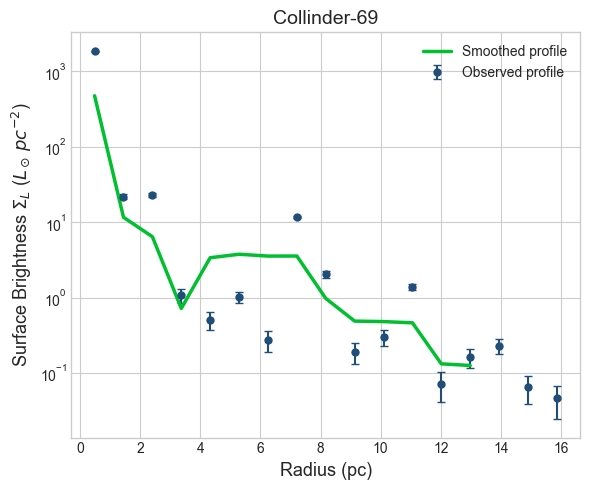

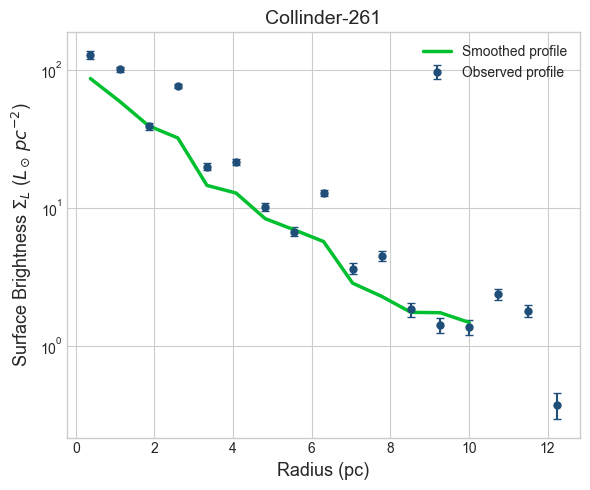

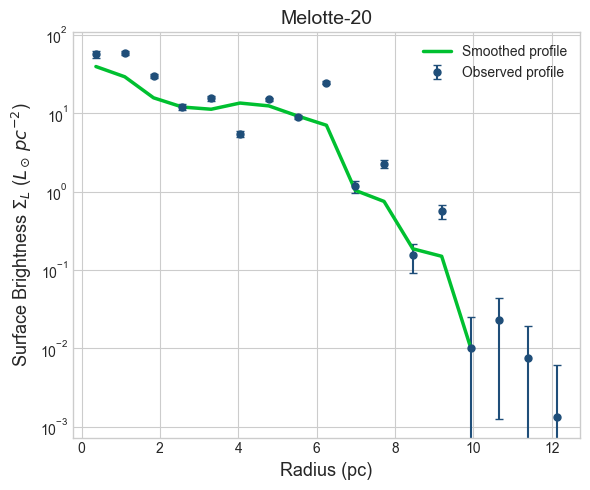

/var/folders/sp/ffpms7dn7w197xlmhjxwls700000gn/T/ipykernel_26882/3352358577.py:72: DtypeWarning: Columns (176,182,204,207) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


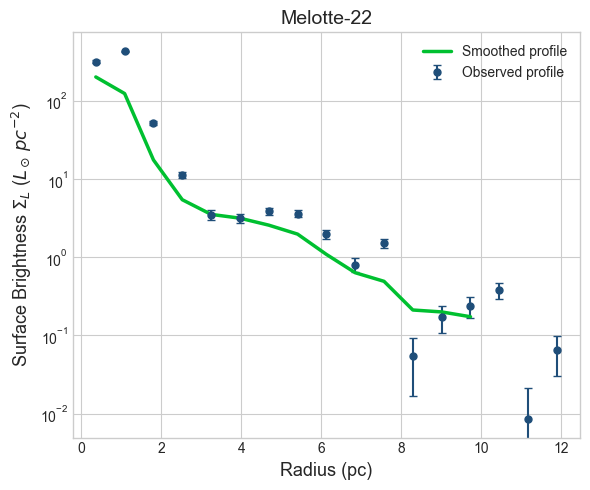

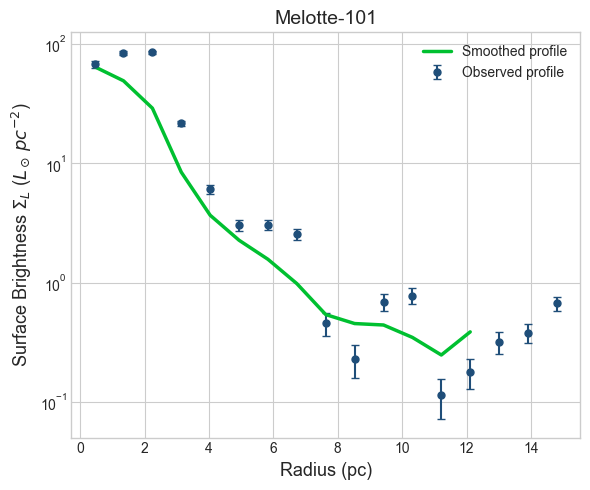

/var/folders/sp/ffpms7dn7w197xlmhjxwls700000gn/T/ipykernel_26882/3352358577.py:72: DtypeWarning: Columns (182) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


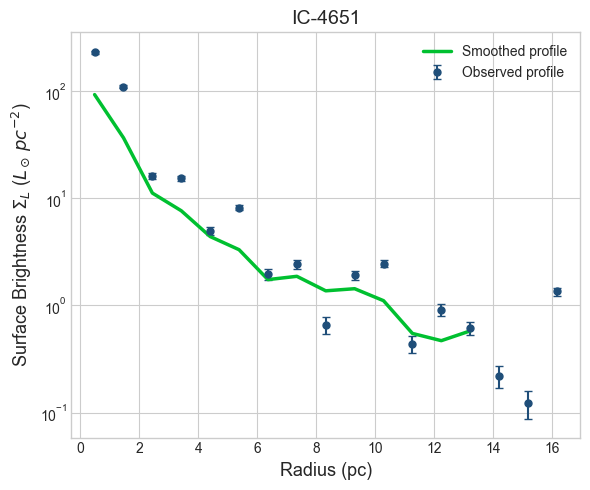

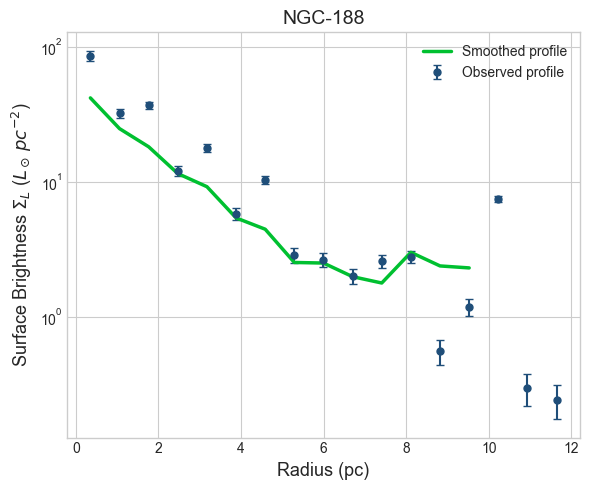

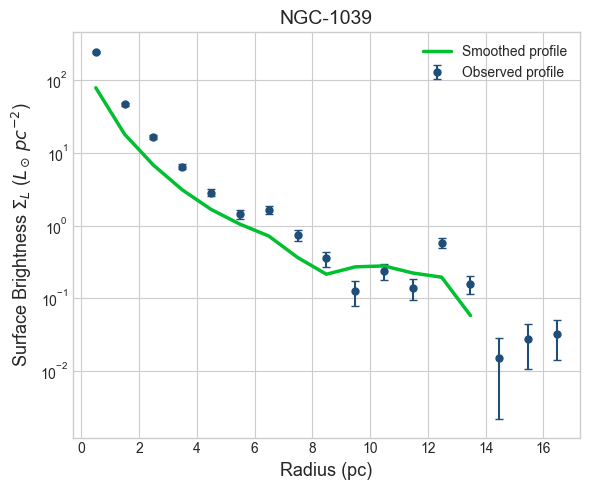

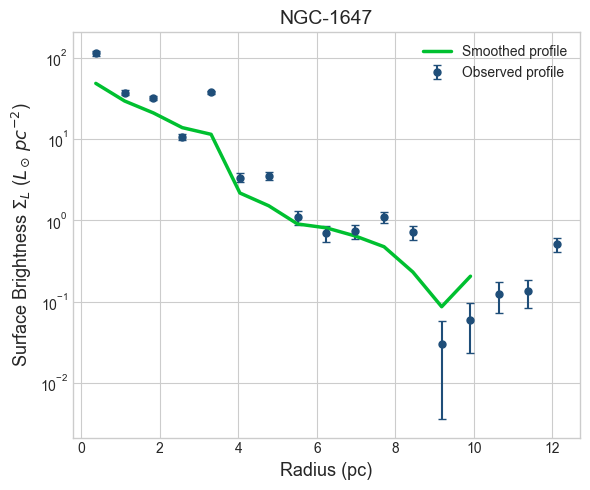

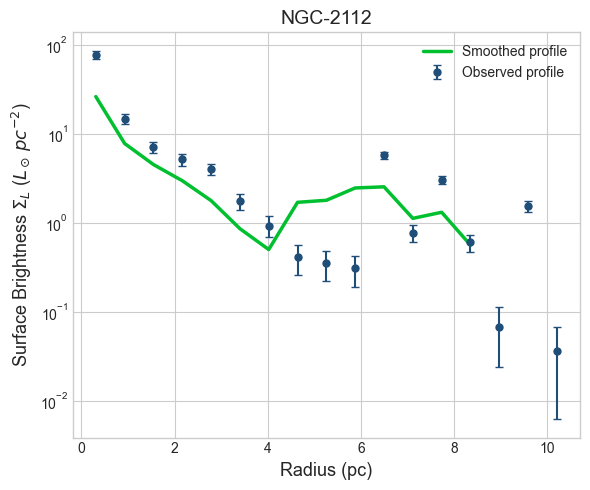

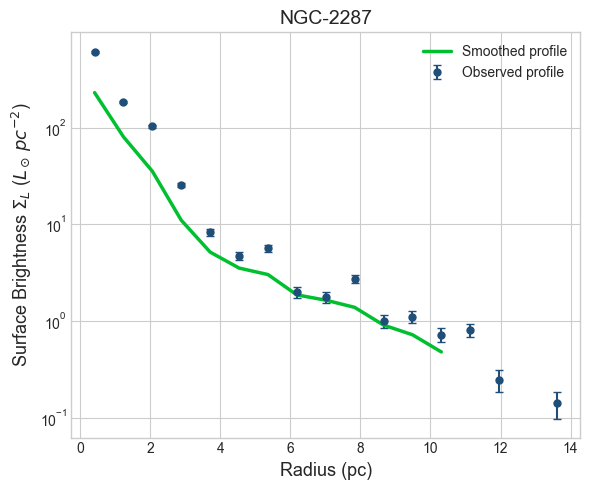

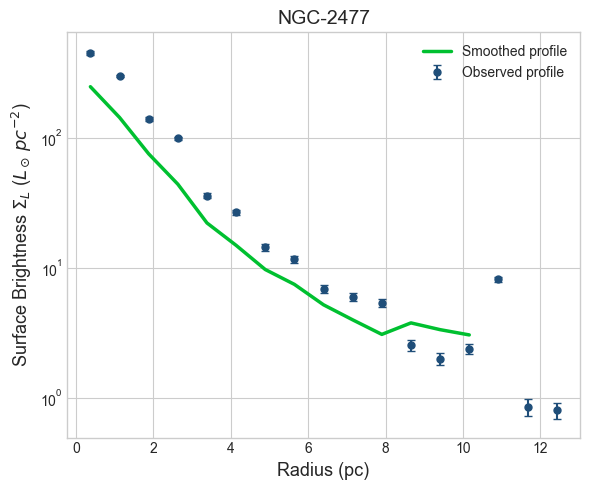

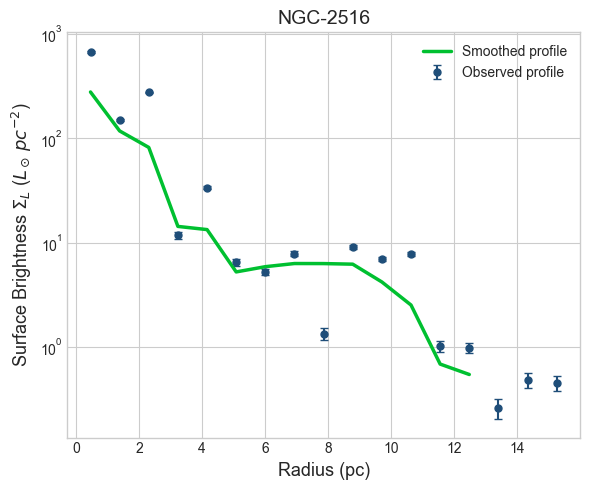

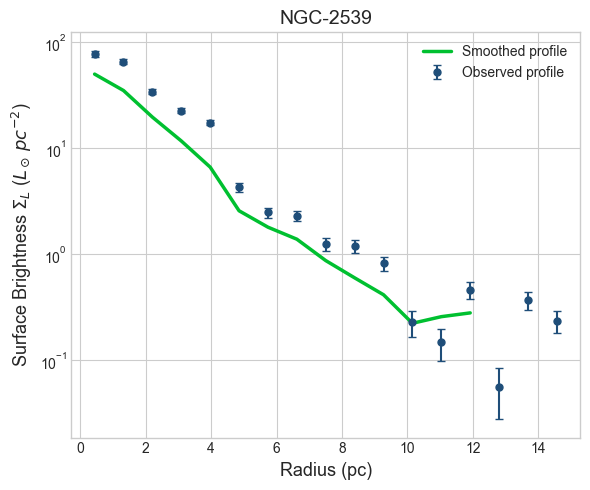

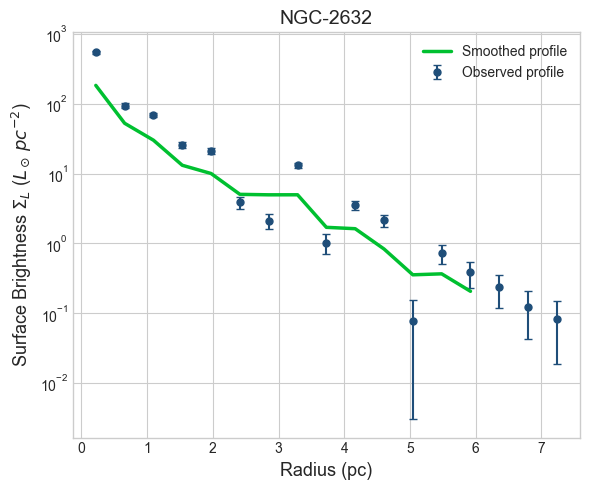

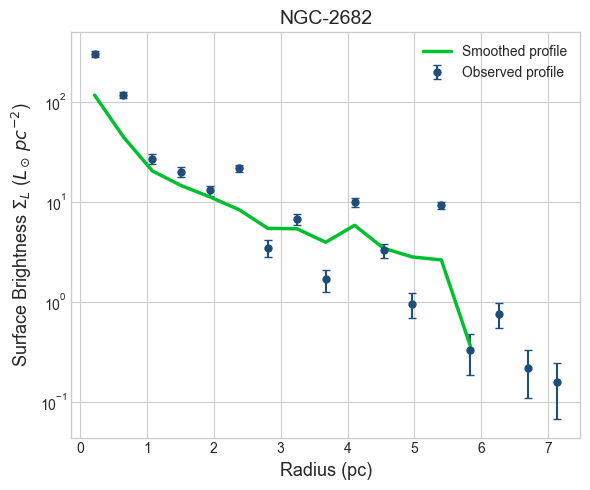

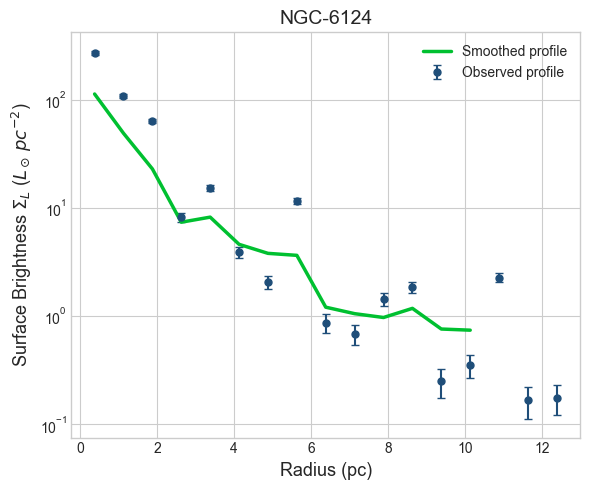

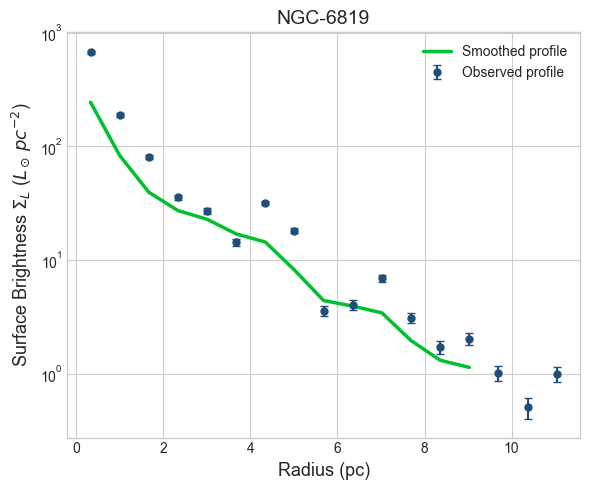

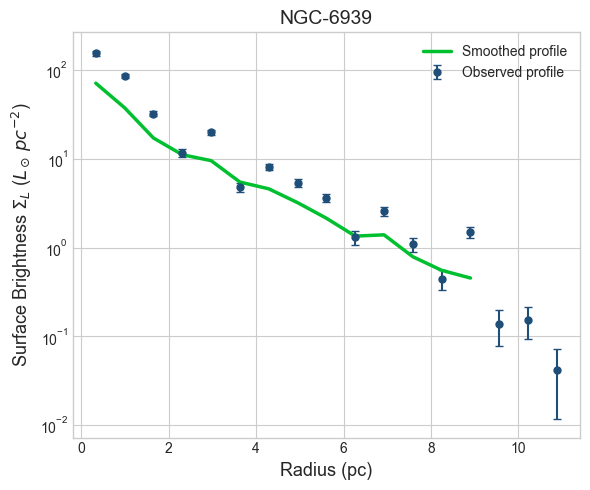

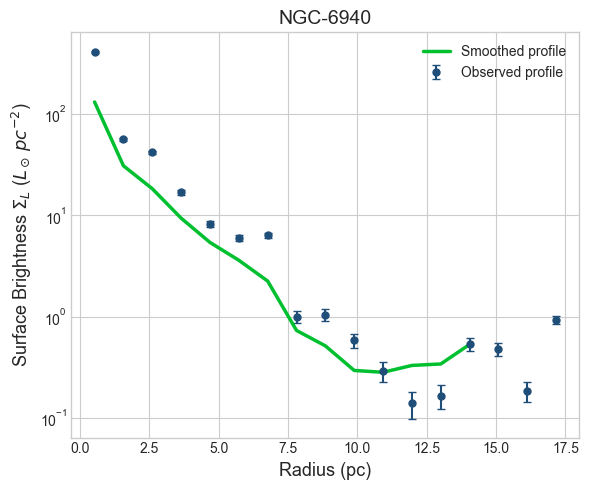

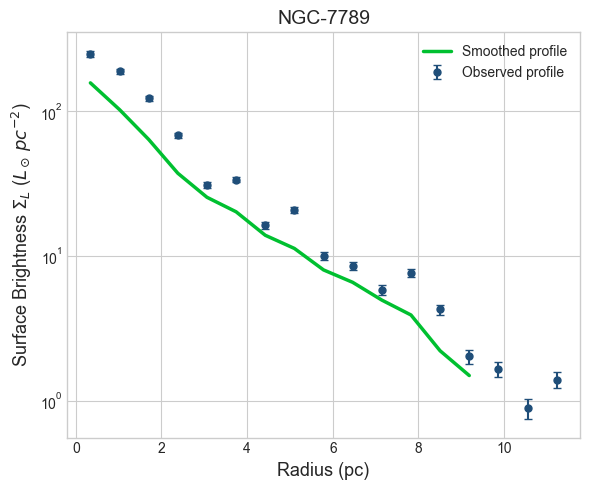

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# Load cluster centres
# -------------------------------------------------

centres = pd.read_csv("/Users/prernadwivedi/Downloads/21 clusters/cluster_centres_with_distance.csv")

centres["Cluster_clean"] = (
    centres["Cluster"]
    .str.replace("-", "", regex=False)
    .str.replace(" ", "", regex=False)
    .str.lower()
)

# -------------------------------------------------
# Distance dictionary
# -------------------------------------------------

cluster_distances = {
"collinder261":2634,"collinder69":396,"ic4651":908,"melotte101":1728,
"melotte20":180,"melotte22":150,"ngc1039":533,"ngc1647":520,"ngc188":1746,
"ngc2112":778,"ngc2477":1263,"ngc2287":641,"ngc2516":414,"ngc2539":1176,
"ngc2632":174,"ngc2682":501,"ngc6124":501,"ngc6819":2056,"ngc6939":1422,
"ngc6940":1061,"ngc7789":1421
}

# -------------------------------------------------
# Gaia files
# -------------------------------------------------

gaia_files = [
"/Users/prernadwivedi/Downloads/21 clusters/Collinder_69_final (1).csv",
"/Users/prernadwivedi/Downloads/21 clusters/Collinder_261_final.csv",
"/Users/prernadwivedi/Downloads/21 clusters/Melotte_20_final.csv",
"/Users/prernadwivedi/Downloads/21 clusters/aptc_melotte_22.csv",
"/Users/prernadwivedi/Downloads/21 clusters/Melotte_101_final.csv",
"/Users/prernadwivedi/Downloads/21 clusters/aptc_IC_4651.csv",
"/Users/prernadwivedi/Downloads/21 clusters/NGC_188_final.csv",
"/Users/prernadwivedi/Downloads/21 clusters/NGC_1039_final.csv",
"/Users/prernadwivedi/Downloads/21 clusters/NGC_1647_final.csv",
"/Users/prernadwivedi/Downloads/21 clusters/NGC_2112_final.csv",
"/Users/prernadwivedi/Downloads/21 clusters/NGC_2287_final.csv",
"/Users/prernadwivedi/Downloads/21 clusters/NGC_2477_final.csv",
"/Users/prernadwivedi/Downloads/21 clusters/NGC_2516_final.csv",
"/Users/prernadwivedi/Downloads/21 clusters/NGC_2539_final.csv",
"/Users/prernadwivedi/Downloads/21 clusters/NGC_2632_final.csv",
"/Users/prernadwivedi/Downloads/21 clusters/NGC_2682_final.csv",
"/Users/prernadwivedi/Downloads/21 clusters/NGC_6124_final.csv",
"/Users/prernadwivedi/Downloads/21 clusters/NGC_6819_final.csv",
"/Users/prernadwivedi/Downloads/21 clusters/NGC_6939_final.csv",
"/Users/prernadwivedi/Downloads/21 clusters/NGC_6940_final.csv",
"/Users/prernadwivedi/Downloads/21 clusters/NGC_7789_final.csv"
]

M_G_sun = 4.67

# -------------------------------------------------
# Plot style (professional)
# -------------------------------------------------

plt.style.use("seaborn-v0_8-whitegrid")

# -------------------------------------------------
# Loop over clusters
# -------------------------------------------------

for file_path in gaia_files:

    df = pd.read_csv(file_path)

    cluster_name = df["cluster_name"].iloc[0]
    cluster_clean = cluster_name.replace("-","").replace(" ","").lower()

    row = centres[centres["Cluster_clean"] == cluster_clean]
    if row.empty:
        continue

    ra0 = row["RA_KDE_deg"].iloc[0]
    dec0 = row["Dec_KDE_deg"].iloc[0]
    P_thresh = row["Membership_threshold"].iloc[0]

    if cluster_clean not in cluster_distances:
        continue

    d_pc = cluster_distances[cluster_clean]

    # Membership selection
    df = df[df["cluster_membership"] >= P_thresh]

    if len(df) < 50:
        continue

    # -------------------------------------------------
    # Projected radius
    # -------------------------------------------------

    ra = np.radians(df["RA_ICRS"].values)
    dec = np.radians(df["DE_ICRS"].values)

    ra0_rad = np.radians(ra0)
    dec0_rad = np.radians(dec0)

    theta = np.sqrt(((ra-ra0_rad)*np.cos(dec0_rad))**2 + (dec-dec0_rad)**2)

    R = theta * d_pc

    # -------------------------------------------------
    # Luminosity
    # -------------------------------------------------

    M_G = df["phot_g_mean_mag"].values - 5*np.log10(d_pc/10)

    L = 10**(-0.4*(M_G - M_G_sun))

    # -------------------------------------------------
    # Radial bins
    # -------------------------------------------------

    bins = np.linspace(0, np.percentile(R,95), 18)

    R_mid = []
    Sigma_L = []
    Sigma_err = []

    for i in range(len(bins)-1):

        mask = (R>=bins[i]) & (R<bins[i+1])
        N = np.sum(mask)

        if N < 5:
            continue

        area = np.pi*(bins[i+1]**2 - bins[i]**2)

        L_total = np.sum(L[mask])

        R_mid.append((bins[i]+bins[i+1])/2)
        Sigma_L.append(L_total/area)

        # Poisson uncertainty
        Sigma_err.append(np.sqrt(L_total)/area)

    if len(R_mid) < 4:
        continue

    R_mid = np.array(R_mid)
    Sigma_L = np.array(Sigma_L)
    Sigma_err = np.array(Sigma_err)

    # -------------------------------------------------
    # Smooth profile
    # -------------------------------------------------

    window = min(4, len(Sigma_L))

    Sigma_smooth = np.convolve(Sigma_L, np.ones(window)/window, mode="valid")
    R_smooth = R_mid[:len(Sigma_smooth)]

    # -------------------------------------------------
    # Plot
    # -------------------------------------------------

    plt.figure(figsize=(6,5))

    plt.errorbar(
        R_mid,
        Sigma_L,
        yerr=Sigma_err,
        fmt="o",
        color="#1f4e79",
        markersize=5,
        capsize=3,
        label="Observed profile"
    )

    plt.plot(
        R_smooth,
        Sigma_smooth,
        color="#00c030",
        linewidth=2.5,
        label="Smoothed profile"
    )

    plt.yscale("log")

    plt.xlabel("Radius (pc)",fontsize=13)
    plt.ylabel(r"Surface Brightness $\Sigma_L$ ($L_\odot\,pc^{-2}$)",fontsize=13)

    plt.title(cluster_name,fontsize=14)

    plt.legend(frameon=False)

    plt.tight_layout()

    plt.show()